# Phase Boundary by n_c

This notebook loads a `results_per_run_*.csv` file from a balanced 2D phase-diagram run and reproduces the phase-boundary characterization, but **for every** `n_c` instead of only the largest dataset size.


In [20]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set this manually if you want a specific cache. Leave as None to auto-pick the newest balanced run.
CSV_PATH = None
PHASE_THRESHOLD = 0.20

if CSV_PATH is None:
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents]
    csv_candidates = []
    for root in search_roots:
        csv_candidates.extend(
            root.glob('phase2d_mnist_balanced_perclass_noreplace_v3_*/data/results_per_run_phase2d_mnist_balanced_perclass_noreplace_v3_*.csv')
        )
        csv_candidates.extend(
            root.glob('noisy_mnist/phase_diagram_2d/phase2d_mnist_balanced_perclass_noreplace_v3_*/data/results_per_run_phase2d_mnist_balanced_perclass_noreplace_v3_*.csv')
        )
    csv_candidates = sorted({p.resolve() for p in csv_candidates}, key=lambda p: p.stat().st_mtime)
    if not csv_candidates:
        raise FileNotFoundError('No balanced phase-diagram per-run CSV found.')
    CSV_PATH = csv_candidates[-1]
else:
    CSV_PATH = Path(CSV_PATH).resolve()

CACHE_DIR = CSV_PATH.parents[1]
FIGURES_DIR = CACHE_DIR / 'figures_notebook'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH, CACHE_DIR, FIGURES_DIR


(PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_mnist_balanced_perclass_noreplace_v3_r5_e20_p0.9000-0.9950_b16-54120_tpc500-5412_w512_lr0.01_logtr100_logte500/data/results_per_run_phase2d_mnist_balanced_perclass_noreplace_v3_r5_e20_p0.9000-0.9950_b16-54120_tpc500-5412_w512_lr0.01_logtr100_logte500.csv'),
 PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_mnist_balanced_perclass_noreplace_v3_r5_e20_p0.9000-0.9950_b16-54120_tpc500-5412_w512_lr0.01_logtr100_logte500'),
 PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_mnist_balanced_perclass_noreplace_v3_r5_e20_p0.9000-0.9950_b16-54120_tpc500-5412_w512_lr0.01_logtr100_logte500/figures_notebook'))

In [21]:
df = pd.read_csv(CSV_PATH)
if 'train_samples_per_class' not in df.columns:
    df['train_samples_per_class'] = (df['N'] // 10).astype(int)

df = df.sort_values(['train_samples_per_class', 'batch_size', 'p', 'seed']).reset_index(drop=True)
df.head()


,p,batch_size,effective_batch_size,train_samples_per_class,requested_train_samples_per_class,N,requested_N,test_samples_per_class,test_N,seed,width,total_samples_seen,num_steps,final_test_accuracy,final_test_loss,final_train_loss
0,0.9,16,16,500,500,5000,5000,892,8920,0,512,100000,6250,0.700561,0.968356,1.963829
1,0.9,16,16,500,500,5000,5000,892,8920,1,512,100000,6250,0.709865,0.972680,2.044818
2,0.9,16,16,500,500,5000,5000,892,8920,2,512,100000,6250,0.707960,0.954449,2.048842
3,0.9,16,16,500,500,5000,5000,892,8920,3,512,100000,6250,0.709865,0.985966,2.000996
4,0.9,16,16,500,500,5000,5000,892,8920,4,512,100000,6250,0.727578,0.944537,2.027091


In [22]:
def aggregate_by_mean(frame: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        frame.groupby(['train_samples_per_class', 'N', 'batch_size', 'p'], as_index=False)
        .agg(
            mean_accuracy=('final_test_accuracy', 'mean'),
            std_accuracy=('final_test_accuracy', 'std'),
            count=('final_test_accuracy', 'count'),
        )
    )
    grouped['std_accuracy'] = grouped['std_accuracy'].fillna(0.0)
    return grouped


def enforce_nonincreasing(values):
    values = list(map(float, values))
    if not values:
        return []
    out = [values[0]]
    for value in values[1:]:
        out.append(min(out[-1], value))
    return out


def estimate_crossing(ps, accs, threshold):
    ps = list(map(float, ps))
    accs = enforce_nonincreasing(accs)
    if len(ps) < 2:
        return None
    for i in range(1, len(ps)):
        prev_acc = accs[i - 1]
        curr_acc = accs[i]
        if prev_acc >= threshold >= curr_acc:
            p0 = ps[i - 1]
            p1 = ps[i]
            if abs(curr_acc - prev_acc) < 1e-12:
                return p1
            frac = (threshold - prev_acc) / (curr_acc - prev_acc)
            return p0 + frac * (p1 - p0)
    return None


def fit_phase_boundary(batch_sizes, p_critical):
    valid = [
        (float(batch_size), float(pc))
        for batch_size, pc in zip(batch_sizes, p_critical)
        if np.isfinite(pc) and 0.0 < 1.0 - pc < 1.0
    ]
    if len(valid) < 2:
        return None
    x = np.log([batch_size for batch_size, _ in valid])
    y = np.log([1.0 - pc for _, pc in valid])
    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = intercept + slope * x
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    return {
        'a': float(np.exp(intercept)),
        'beta': float(-slope),
        'r2': float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan'),
    }


agg = aggregate_by_mean(df)
agg.head()


,train_samples_per_class,N,batch_size,p,mean_accuracy,std_accuracy,count
0,500,5000,16,0.900000,0.711166,0.009944,5
1,500,5000,16,0.903276,0.707309,0.010763,5
2,500,5000,16,0.906552,0.700964,0.009662,5
3,500,5000,16,0.909828,0.694888,0.009876,5
4,500,5000,16,0.913103,0.689350,0.009981,5


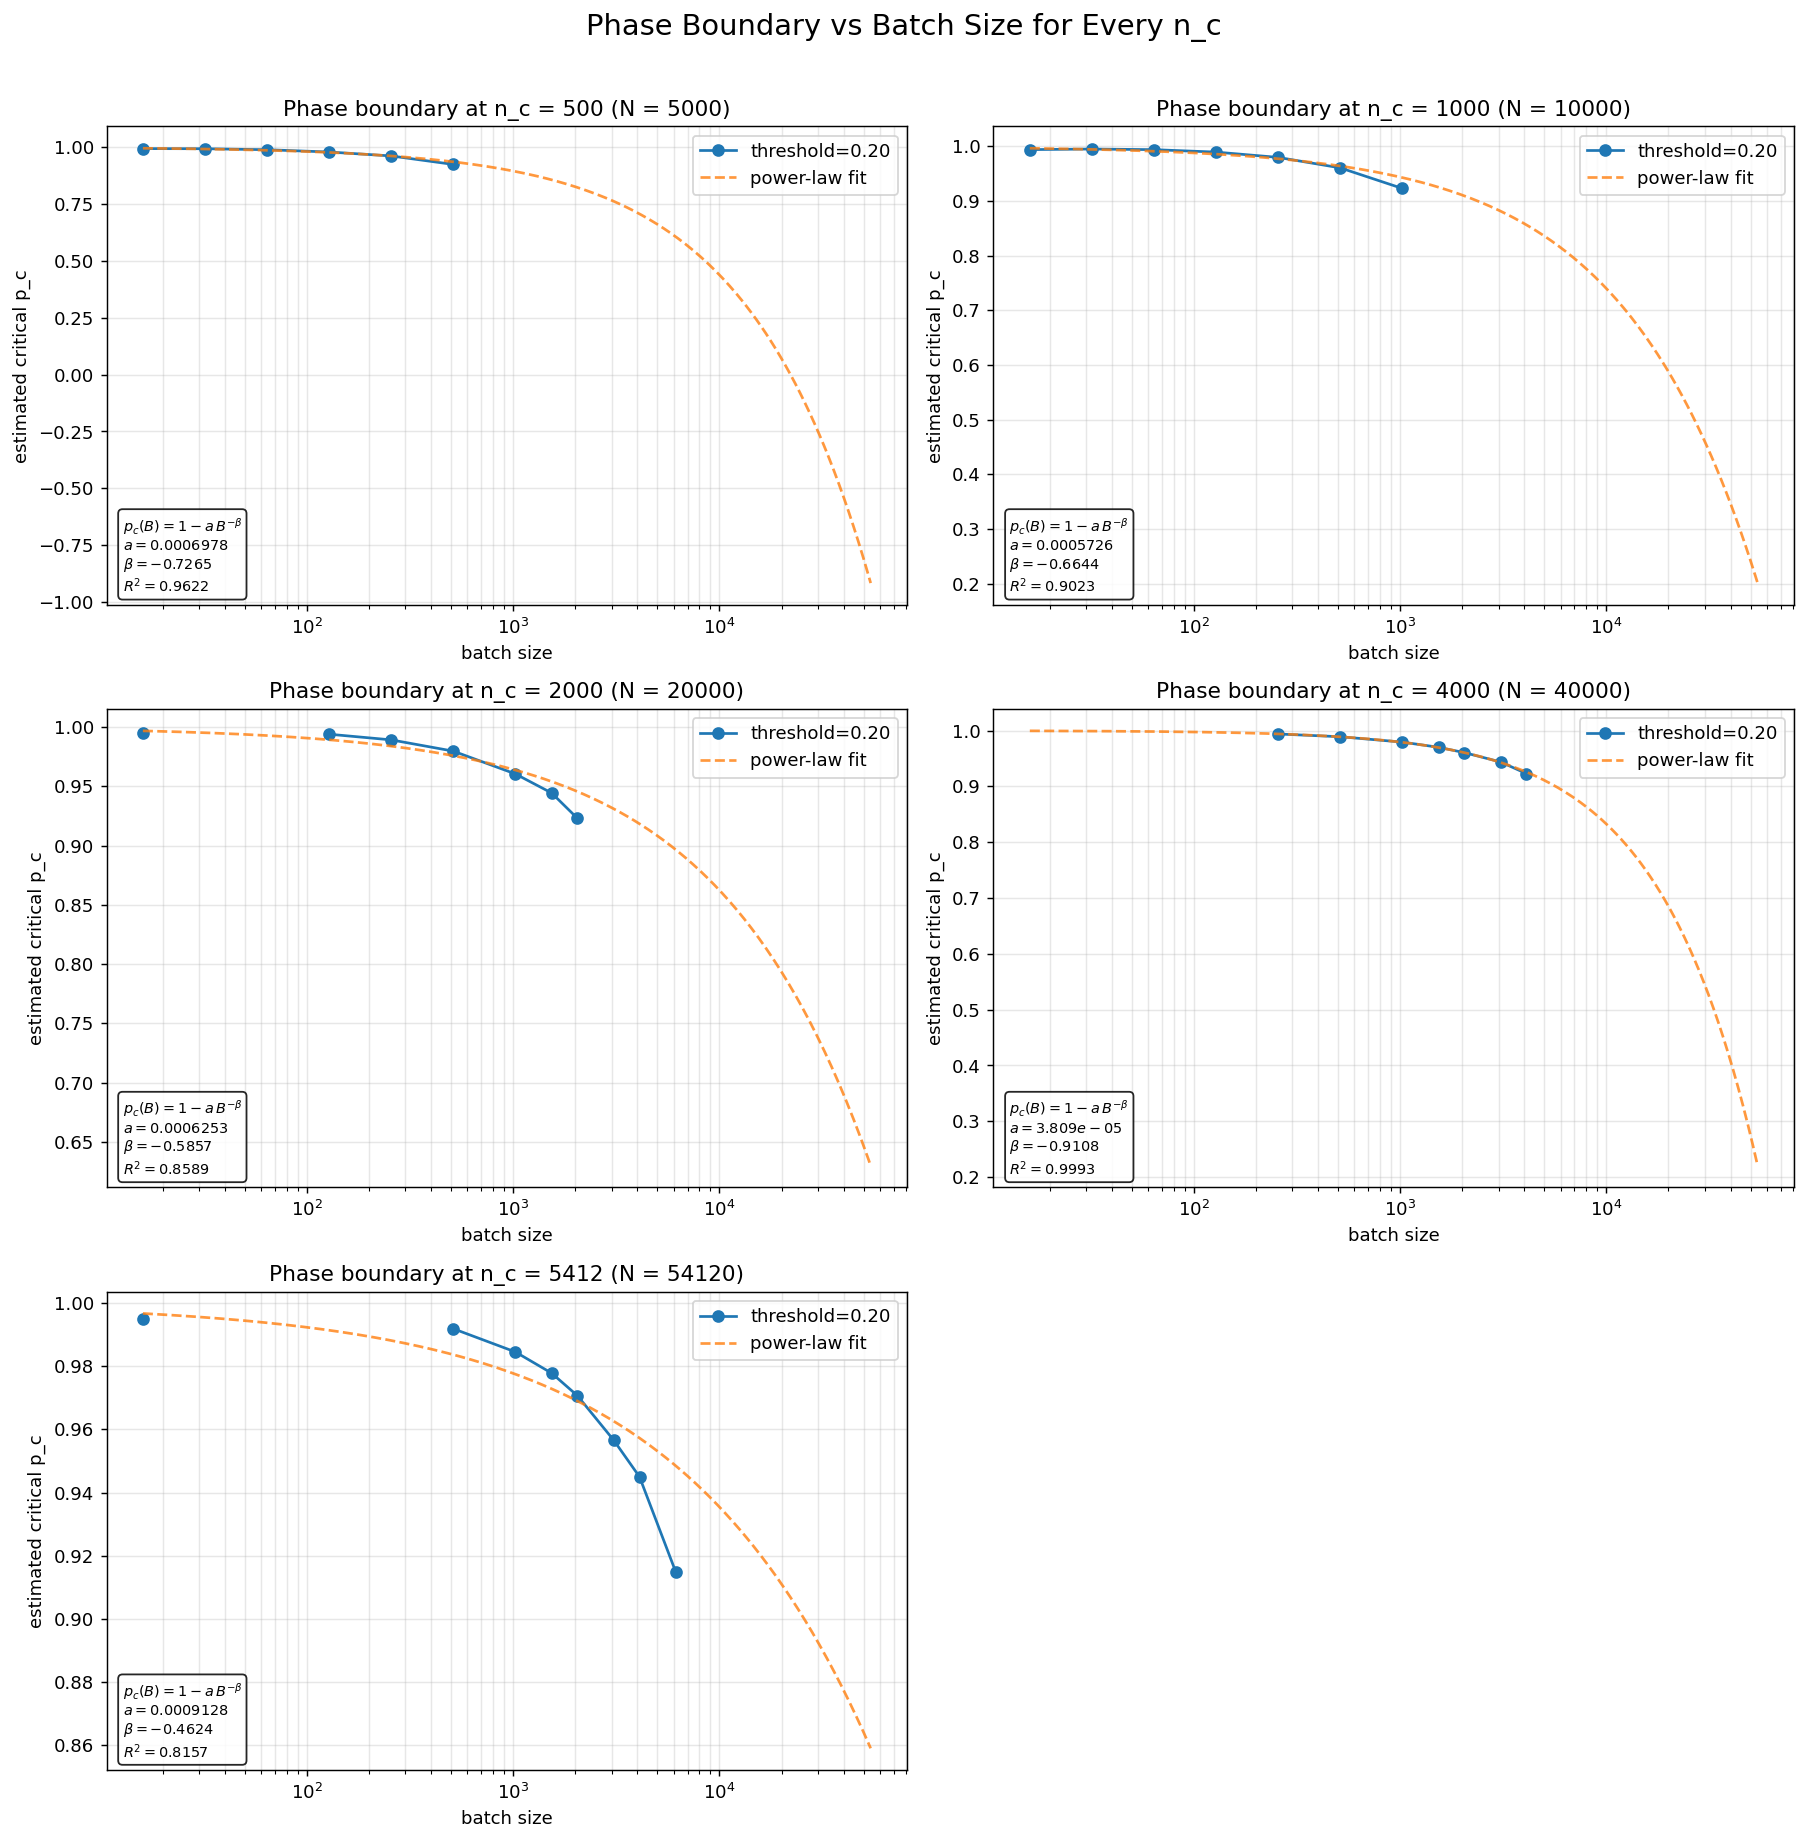

(PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_mnist_balanced_perclass_noreplace_v3_r5_e20_p0.9000-0.9950_b16-54120_tpc500-5412_w512_lr0.01_logtr100_logte500/figures_notebook/phase_boundary_by_nc_notebook.pdf'),
 PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_mnist_balanced_perclass_noreplace_v3_r5_e20_p0.9000-0.9950_b16-54120_tpc500-5412_w512_lr0.01_logtr100_logte500/figures_notebook/phase_boundary_by_nc_notebook.png'))

In [23]:
nc_values = sorted(agg['train_samples_per_class'].unique())
batch_sizes = sorted(agg['batch_size'].unique())
p_values = sorted(agg['p'].unique())

ncols = 2
nrows = math.ceil(len(nc_values) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(7.0 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.ravel()

for ax, n_c in zip(axes_flat, nc_values):
    sub = agg[agg['train_samples_per_class'] == n_c].copy()
    total_n = int(sub['N'].iloc[0])
    pcs = []
    for batch_size in batch_sizes:
        curve = sub[sub['batch_size'] == batch_size].sort_values('p')
        pc = estimate_crossing(curve['p'].tolist(), curve['mean_accuracy'].tolist(), PHASE_THRESHOLD)
        pcs.append(float('nan') if pc is None else float(pc))

    ax.plot(batch_sizes, pcs, marker='o', label=fr'threshold={PHASE_THRESHOLD:.2f}')
    fit = fit_phase_boundary(batch_sizes, pcs)
    textbox = None
    if fit is not None:
        batch_grid = np.geomspace(min(batch_sizes), max(batch_sizes), 300)
        fit_curve = 1.0 - fit['a'] * np.power(batch_grid, -fit['beta'])
        ax.plot(batch_grid, fit_curve, linestyle='--', alpha=0.8, label='power-law fit')
        textbox = '\n'.join([
            r'$p_c(B) = 1 - a\, B^{-\beta}$',
            fr'$a = {fit["a"]:.4g}$',
            fr'$\beta = {fit["beta"]:.4f}$',
            fr'$R^2 = {fit["r2"]:.4f}$',
        ])

    ax.set_xscale('log')
    ax.set_xlabel('batch size')
    ax.set_ylabel('estimated critical p_c')
    ax.set_title(f'Phase boundary at n_c = {n_c} (N = {total_n})')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    if textbox is not None:
        ax.text(
            0.02,
            0.02,
            textbox,
            transform=ax.transAxes,
            fontsize=8,
            va='bottom',
            ha='left',
            bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85},
        )

for ax in axes_flat[len(nc_values):]:
    ax.set_axis_off()

fig.suptitle('Phase Boundary vs Batch Size for Every n_c', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])

out_pdf = FIGURES_DIR / 'phase_boundary_by_nc_notebook.pdf'
out_png = FIGURES_DIR / 'phase_boundary_by_nc_notebook.png'
fig.savefig(out_pdf, bbox_inches='tight')
fig.savefig(out_png, bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

out_pdf, out_png


In [24]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import TwoSlopeNorm


def format_train_size_label(total_n: int) -> str:
    n_c = int(round(total_n / 10))
    return f'n_c = {n_c} (N = {total_n})'


def aggregate_export(frame: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        frame.groupby(['train_samples_per_class', 'N', 'batch_size', 'p'], as_index=False)
        .agg(
            mean_accuracy=('final_test_accuracy', 'mean'),
            std_accuracy=('final_test_accuracy', 'std'),
            mean_test_loss=('final_test_loss', 'mean'),
            std_test_loss=('final_test_loss', 'std'),
            mean_train_loss=('final_train_loss', 'mean'),
            std_train_loss=('final_train_loss', 'std'),
            count=('final_test_accuracy', 'count'),
        )
        .sort_values(['train_samples_per_class', 'batch_size', 'p'])
        .reset_index(drop=True)
    )
    for col in ['std_accuracy', 'std_test_loss', 'std_train_loss']:
        grouped[col] = grouped[col].fillna(0.0)
    return grouped


def linear_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5], dtype=float)
    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - 0.5 * (values[1] - values[0])
    right = values[-1] + 0.5 * (values[-1] - values[-2])
    return np.concatenate([[left], mids, [right]])


def log_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] / np.sqrt(2.0), values[0] * np.sqrt(2.0)], dtype=float)
    mids = np.sqrt(values[:-1] * values[1:])
    left = values[0] ** 2 / mids[0]
    right = values[-1] ** 2 / mids[-1]
    return np.concatenate([[left], mids, [right]])


def build_metric_grid(frame, n_value, batch_sizes, p_values, metric_key):
    grid = np.full((len(batch_sizes), len(p_values)), np.nan, dtype=float)
    sub = frame[frame['N'] == n_value]
    for i, batch_size in enumerate(batch_sizes):
        row = sub[sub['batch_size'] == batch_size].set_index('p')
        for j, p in enumerate(p_values):
            if p in row.index:
                value = row.loc[p, metric_key]
                if isinstance(value, pd.Series):
                    value = value.iloc[0]
                grid[i, j] = float(value)
    return grid


def add_accuracy_heatmap(ax, batch_sizes, p_values, grid, title, contour_threshold):
    norm = TwoSlopeNorm(vmin=0.0, vcenter=0.10, vmax=1.0)
    mesh = ax.pcolormesh(
        linear_edges(p_values),
        log_edges(batch_sizes),
        grid,
        shading='auto',
        cmap='coolwarm',
        norm=norm,
    )
    if np.isfinite(grid).sum() >= 4:
        p_mesh, b_mesh = np.meshgrid(p_values, batch_sizes)
        try:
            ax.contour(p_mesh, b_mesh, grid, levels=[PHASE_THRESHOLD], colors='black', linewidths=1.1)
        except ValueError:
            pass
    ax.set_title(title)
    ax.set_xlabel('corruption probability p')
    ax.set_ylabel('batch size')
    ax.set_yscale('log')
    ax.set_yticks(batch_sizes)
    ax.set_yticklabels([str(x) for x in batch_sizes])
    return mesh


def add_scalar_heatmap(ax, batch_sizes, p_values, grid, title, cmap='viridis'):
    finite = grid[np.isfinite(grid)]
    if finite.size:
        vmin = float(np.min(finite))
        vmax = float(np.max(finite))
        if abs(vmax - vmin) < 1e-12:
            vmax = vmin + 1e-12
    else:
        vmin, vmax = 0.0, 1.0
    mesh = ax.pcolormesh(
        linear_edges(p_values),
        log_edges(batch_sizes),
        grid,
        shading='auto',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel('corruption probability p')
    ax.set_ylabel('batch size')
    ax.set_yscale('log')
    ax.set_yticks(batch_sizes)
    ax.set_yticklabels([str(x) for x in batch_sizes])
    return mesh


def add_page(pdf, fig):
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)


def choose_fixed_p_values(p_values, target_count=10):
    available = np.asarray(sorted({float(p) for p in p_values if 0.90 <= float(p) <= 1.0}), dtype=float)
    if available.size <= target_count:
        return available.tolist()
    targets = np.linspace(0.90, min(1.0, float(available.max())), target_count)
    chosen = []
    used = set()
    for target in targets:
        order = np.argsort(np.abs(available - target))
        picked = None
        for idx in order:
            value = float(available[idx])
            key = round(value, 12)
            if key not in used:
                used.add(key)
                chosen.append(value)
                picked = value
                break
        if picked is None:
            break
    return sorted(chosen)


def plot_metric_vs_p_pages(pdf, aggregated, batch_sizes, p_values, n_values, metric_key, error_key, y_label, page_title):
    plots_per_page = 6
    for start in range(0, len(batch_sizes), plots_per_page):
        page_batch_sizes = batch_sizes[start:start + plots_per_page]
        fig, axes = plt.subplots(2, 3, figsize=(14, 8.5), squeeze=False)
        axes_flat = axes.ravel()
        for ax, batch_size in zip(axes_flat, page_batch_sizes):
            for n_value in n_values:
                sub = aggregated[(aggregated['N'] == n_value) & (aggregated['batch_size'] == batch_size)].sort_values('p')
                if sub.empty:
                    continue
                ax.errorbar(
                    sub['p'],
                    sub[metric_key],
                    yerr=sub[error_key],
                    fmt='-o',
                    linewidth=1.2,
                    markersize=4,
                    capsize=2,
                    elinewidth=0.9,
                    label=format_train_size_label(int(n_value)),
                )
            ax.set_title(f'B = {batch_size}')
            ax.set_xlabel('p')
            ax.set_ylabel(y_label)
            ax.grid(True, alpha=0.3)
            if ax.lines:
                ax.legend(fontsize=8)
        for ax in axes_flat[len(page_batch_sizes):]:
            ax.set_axis_off()
        fig.suptitle(page_title, fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        add_page(pdf, fig)


def plot_metric_vs_batch_pages(pdf, aggregated, batch_sizes, p_values, n_values, metric_key, error_key, y_label, page_title):
    fixed_p_values = choose_fixed_p_values(p_values, target_count=10)
    if not fixed_p_values:
        return
    fig, axes = plt.subplots(2, 5, figsize=(18, 8.5), squeeze=False)
    axes_flat = axes.ravel()
    for ax, p in zip(axes_flat, fixed_p_values):
        for n_value in n_values:
            sub = aggregated[(aggregated['N'] == n_value) & np.isclose(aggregated['p'], p)].sort_values('batch_size')
            if sub.empty:
                continue
            ax.errorbar(
                sub['batch_size'],
                sub[metric_key],
                yerr=sub[error_key],
                fmt='-o',
                linewidth=1.2,
                markersize=4,
                capsize=2,
                elinewidth=0.9,
                label=format_train_size_label(int(n_value)),
            )
        ax.set_xscale('log')
        ax.set_title(f'p = {p:.4f}')
        ax.set_xlabel('batch size')
        ax.set_ylabel(y_label)
        ax.grid(True, which='both', alpha=0.3)
        if ax.lines:
            ax.legend(fontsize=7)
    for ax in axes_flat[len(fixed_p_values):]:
        ax.set_axis_off()
    fig.suptitle(page_title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    add_page(pdf, fig)


export_df = df.copy()
if 'train_samples_per_class' not in export_df.columns:
    export_df['train_samples_per_class'] = (export_df['N'] // 10).astype(int)

agg_export = aggregate_export(export_df)
nc_values_export = sorted(agg_export['train_samples_per_class'].unique())
n_values_export = sorted(agg_export['N'].unique())
batch_sizes_export = sorted(agg_export['batch_size'].unique())
p_values_export = sorted(agg_export['p'].unique())

combined_pdf_path = CACHE_DIR / 'figures' / f'phase_diagram_characterizations_{CACHE_DIR.name}.pdf'
combined_pdf_path.parent.mkdir(parents=True, exist_ok=True)

with PdfPages(combined_pdf_path) as pdf:
    max_n = max(n_values_export)

    grid = build_metric_grid(agg_export, max_n, batch_sizes_export, p_values_export, 'mean_accuracy')
    if np.isfinite(grid).any():
        fig, ax = plt.subplots(figsize=(9, 5.5))
        mesh = add_accuracy_heatmap(
            ax,
            batch_sizes_export,
            p_values_export,
            grid,
            f'MNIST phase diagram ({format_train_size_label(int(max_n))})',
            PHASE_THRESHOLD,
        )
        cbar = fig.colorbar(mesh, ax=ax)
        cbar.set_label('mean clean test accuracy')
        fig.tight_layout()
        add_page(pdf, fig)

    fig, axes = plt.subplots(1, len(nc_values_export), figsize=(5.2 * len(nc_values_export), 4.5), squeeze=False)
    axes_flat = axes.ravel()
    for ax, n_c in zip(axes_flat, nc_values_export):
        sub = agg_export[agg_export['train_samples_per_class'] == n_c].copy()
        total_n = int(sub['N'].iloc[0])
        pcs = []
        for batch_size in batch_sizes_export:
            curve = sub[sub['batch_size'] == batch_size].sort_values('p')
            pc = estimate_crossing(curve['p'].tolist(), curve['mean_accuracy'].tolist(), PHASE_THRESHOLD)
            pcs.append(float('nan') if pc is None else float(pc))
        ax.plot(batch_sizes_export, pcs, marker='o', label=fr'threshold={PHASE_THRESHOLD:.2f}')
        fit = fit_phase_boundary(batch_sizes_export, pcs)
        if fit is not None:
            batch_grid = np.geomspace(min(batch_sizes_export), max(batch_sizes_export), 300)
            fit_curve = 1.0 - fit['a'] * np.power(batch_grid, -fit['beta'])
            ax.plot(batch_grid, fit_curve, linestyle='--', alpha=0.8, label='power-law fit')
            textbox = '\n'.join([
                r'$p_c(B) = 1 - a\, B^{-\beta}$',
                fr'$a = {fit["a"]:.4g}$',
                fr'$\beta = {fit["beta"]:.4f}$',
                fr'$R^2 = {fit["r2"]:.4f}$',
            ])
            ax.text(
                0.02,
                0.02,
                textbox,
                transform=ax.transAxes,
                fontsize=8,
                va='bottom',
                ha='left',
                bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85},
            )
        ax.set_xscale('log')
        ax.set_xlabel('batch size')
        ax.set_ylabel('estimated critical p_c')
        ax.set_title(f'Phase boundary at n_c = {int(n_c)} (N = {total_n})')
        ax.grid(True, which='both', alpha=0.3)
        ax.legend(fontsize=9)
    for ax in axes_flat[len(nc_values_export):]:
        ax.set_axis_off()
    fig.suptitle('Phase Boundary vs Batch Size for Every n_c', fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    add_page(pdf, fig)

    fig, axes = plt.subplots(1, len(n_values_export), figsize=(4.5 * len(n_values_export), 4.5), squeeze=False)
    fig.subplots_adjust(left=0.06, right=0.92, bottom=0.14, top=0.88, wspace=0.30)
    mesh = None
    for idx, n_value in enumerate(n_values_export):
        ax = axes[0, idx]
        grid = build_metric_grid(agg_export, n_value, batch_sizes_export, p_values_export, 'mean_accuracy')
        if not np.isfinite(grid).any():
            ax.set_axis_off()
            ax.set_title(f'{format_train_size_label(int(n_value))} (no data)')
            continue
        mesh = add_accuracy_heatmap(ax, batch_sizes_export, p_values_export, grid, format_train_size_label(int(n_value)), PHASE_THRESHOLD)
    if mesh is not None:
        cax = fig.add_axes([0.935, 0.18, 0.008, 0.64])
        cbar = fig.colorbar(mesh, cax=cax)
        cbar.set_label('mean clean test accuracy')
    add_page(pdf, fig)

    plot_metric_vs_p_pages(
        pdf,
        agg_export,
        batch_sizes_export,
        p_values_export,
        n_values_export,
        'mean_accuracy',
        'std_accuracy',
        'mean clean test accuracy',
        'Accuracy vs p by Dataset Size at Fixed Batch Size',
    )
    plot_metric_vs_batch_pages(
        pdf,
        agg_export,
        batch_sizes_export,
        p_values_export,
        n_values_export,
        'mean_accuracy',
        'std_accuracy',
        'mean clean test accuracy',
        'Accuracy vs Batch Size by Dataset Size at Fixed Corruption',
    )

    grid = build_metric_grid(agg_export, max_n, batch_sizes_export, p_values_export, 'mean_test_loss')
    if np.isfinite(grid).any():
        fig, ax = plt.subplots(figsize=(9, 5.5))
        mesh = add_scalar_heatmap(
            ax,
            batch_sizes_export,
            p_values_export,
            grid,
            f'Test-loss phase diagram ({format_train_size_label(int(max_n))})',
            cmap='viridis',
        )
        cbar = fig.colorbar(mesh, ax=ax)
        cbar.set_label('mean clean test loss')
        fig.tight_layout()
        add_page(pdf, fig)

    fig, axes = plt.subplots(1, len(n_values_export), figsize=(4.5 * len(n_values_export), 4.5), squeeze=False)
    fig.subplots_adjust(left=0.06, right=0.92, bottom=0.14, top=0.88, wspace=0.30)
    mesh = None
    for idx, n_value in enumerate(n_values_export):
        ax = axes[0, idx]
        grid = build_metric_grid(agg_export, n_value, batch_sizes_export, p_values_export, 'mean_test_loss')
        if not np.isfinite(grid).any():
            ax.set_axis_off()
            ax.set_title(f'{format_train_size_label(int(n_value))} (no data)')
            continue
        mesh = add_scalar_heatmap(ax, batch_sizes_export, p_values_export, grid, format_train_size_label(int(n_value)), cmap='viridis')
    if mesh is not None:
        cax = fig.add_axes([0.935, 0.18, 0.008, 0.64])
        cbar = fig.colorbar(mesh, cax=cax)
        cbar.set_label('mean clean test loss')
    add_page(pdf, fig)

    plot_metric_vs_p_pages(
        pdf,
        agg_export,
        batch_sizes_export,
        p_values_export,
        n_values_export,
        'mean_test_loss',
        'std_test_loss',
        'mean clean test loss',
        'Test Loss vs p by Dataset Size at Fixed Batch Size',
    )
    plot_metric_vs_batch_pages(
        pdf,
        agg_export,
        batch_sizes_export,
        p_values_export,
        n_values_export,
        'mean_test_loss',
        'std_test_loss',
        'mean clean test loss',
        'Test Loss vs Batch Size by Dataset Size at Fixed Corruption',
    )

    if np.isfinite(agg_export['mean_train_loss']).any():
        grid = build_metric_grid(agg_export, max_n, batch_sizes_export, p_values_export, 'mean_train_loss')
        if np.isfinite(grid).any():
            fig, ax = plt.subplots(figsize=(9, 5.5))
            mesh = add_scalar_heatmap(
                ax,
                batch_sizes_export,
                p_values_export,
                grid,
                f'Train-loss phase diagram ({format_train_size_label(int(max_n))})',
                cmap='magma',
            )
            cbar = fig.colorbar(mesh, ax=ax)
            cbar.set_label('mean final train loss')
            fig.tight_layout()
            add_page(pdf, fig)

        fig, axes = plt.subplots(1, len(n_values_export), figsize=(4.5 * len(n_values_export), 4.5), squeeze=False)
        fig.subplots_adjust(left=0.06, right=0.92, bottom=0.14, top=0.88, wspace=0.30)
        mesh = None
        for idx, n_value in enumerate(n_values_export):
            ax = axes[0, idx]
            grid = build_metric_grid(agg_export, n_value, batch_sizes_export, p_values_export, 'mean_train_loss')
            if not np.isfinite(grid).any():
                ax.set_axis_off()
                ax.set_title(f'{format_train_size_label(int(n_value))} (no data)')
                continue
            mesh = add_scalar_heatmap(ax, batch_sizes_export, p_values_export, grid, format_train_size_label(int(n_value)), cmap='magma')
        if mesh is not None:
            cax = fig.add_axes([0.935, 0.18, 0.008, 0.64])
            cbar = fig.colorbar(mesh, cax=cax)
            cbar.set_label('mean final train loss')
        add_page(pdf, fig)

        plot_metric_vs_p_pages(
            pdf,
            agg_export,
            batch_sizes_export,
            p_values_export,
            n_values_export,
            'mean_train_loss',
            'std_train_loss',
            'mean final train loss',
            'Train Loss vs p by Dataset Size at Fixed Batch Size',
        )
        plot_metric_vs_batch_pages(
            pdf,
            agg_export,
            batch_sizes_export,
            p_values_export,
            n_values_export,
            'mean_train_loss',
            'std_train_loss',
            'mean final train loss',
            'Train Loss vs Batch Size by Dataset Size at Fixed Corruption',
        )

combined_pdf_path


PosixPath('/home/abhuiyan/nnet_error_project/noisy_mnist/phase_diagram_2d/phase2d_mnist_balanced_perclass_noreplace_v3_r5_e20_p0.9000-0.9950_b16-54120_tpc500-5412_w512_lr0.01_logtr100_logte500/figures/phase_diagram_characterizations_phase2d_mnist_balanced_perclass_noreplace_v3_r5_e20_p0.9000-0.9950_b16-54120_tpc500-5412_w512_lr0.01_logtr100_logte500.pdf')